# SVM Classifier Model

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import svm
#from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_validate, GridSearchCV, KFold, cross_val_score
#from sklearn.metrics import recall_score

#from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler



In [434]:
INPUT_DIR        = "data/input"
MODEL_INPUT_DIR  = f"{INPUT_DIR}/formatted-input"
MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_all_traintest.csv"#model_input_all_traintest.csv" #"model_input_imm_and_mhc-nb_m1_t7.csv"#"#"model_input_all_traintest.csv"
ALL_PEPS_FILE    = f"{INPUT_DIR}/cedar_allPeps_traintest.txt"

IMM_PEP_FILE     = f"{INPUT_DIR}/cedar_imm_peps_traintest.txt"  #cedar_Immunogenic_self_df.txt"        #cedar_imm_peps_traintest.txt"
NON_IMM_PEP_FILE = f"{INPUT_DIR}/cedar_non_imm_peps_traintest.txt"      #randselfpeps~10k.txt"#randselfpeps~10k.txt"#random_in_silico_peptides.txt"#non_mhc_binding_peptides.txt"#"

## Load the Data

In [435]:
X_df = pd.read_csv(MODEL_INPUT_FILE)

display(X_df[X_df['peptide'].str.contains('pep')])

,peptide,hla_best_rank,avg_rank,best_netmhc_r,best_mixmhc_r,best_mhcflurry_r,best_mhcnuggets_r,weak_binders_count,strong_binders_count,Num_Tools_Super_Strong_Binder,...,Num_Tools_0_05,Num_Tools_0_10,Num_Tools_0_50,Num_Tools_1,Num_Tools_2,PRIME_%Rank_bestAllele,pathogenicity,selfsimilarity,mtec_expression,tap_score


In [436]:
X_df.drop_duplicates(subset=['peptide'], inplace=True)
X_df.sort_values(by='peptide', inplace=True)

display(X_df)
display(X_df.shape)

,peptide,hla_best_rank,avg_rank,best_netmhc_r,best_mixmhc_r,best_mhcflurry_r,best_mhcnuggets_r,weak_binders_count,strong_binders_count,Num_Tools_Super_Strong_Binder,...,Num_Tools_0_05,Num_Tools_0_10,Num_Tools_0_50,Num_Tools_1,Num_Tools_2,PRIME_%Rank_bestAllele,pathogenicity,selfsimilarity,mtec_expression,tap_score
0,AAAAAAGVL,0.018,0.21350,0.255,0.018,0.081,0.50,145,41,2,...,1,2,3,4,4,0.056,0.703540,0.929204,1,0.5886
1,AAAAAAQQIQV,0.279,2.10500,5.282,0.279,1.199,1.66,24,3,0,...,0,0,1,1,3,2.033,0.492574,0.910891,0,0.4028
2,AAAAAAVAA,0.043,0.31600,0.690,0.043,0.181,0.35,86,27,1,...,1,1,3,4,4,0.078,0.836364,0.945455,1,0.3309
3,AAAAAGVSFTK,0.015,0.10475,0.272,0.062,0.015,0.07,66,22,3,...,1,3,4,4,4,0.300,0.569740,0.841608,0,0.7572
4,AAAACTTMK,0.044,0.36000,0.256,0.044,0.210,0.93,36,16,1,...,1,1,3,4,4,0.018,0.617284,0.858025,0,0.7078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19494,YYVFHMPRCL,0.020,0.29350,0.635,0.104,0.415,0.02,27,6,1,...,1,1,3,4,4,0.142,0.478261,0.680435,0,0.7886
19495,YYVGYLQPRTF,0.014,0.08775,0.046,0.014,0.081,0.21,41,28,3,...,2,3,4,4,4,0.279,1.000000,0.890595,0,0.9316
19496,YYVHEGIRTY,0.005,0.04875,0.033,0.005,0.007,0.15,146,69,3,...,3,3,4,4,4,0.039,1.000000,0.813725,0,0.9371
19497,YYYAGSSRL,0.003,0.01075,0.003,0.019,0.011,0.01,169,61,4,...,4,4,4,4,4,0.080,1.000000,0.861314,0,0.7838


(19499, 27)

In [437]:
immPeps, non_immPeps = set(), set()

def addPeps(fp: str, pepSet: set):
    with open(fp, 'r') as f:
        for line in f:
            if line:
                pepSet.add(line.strip())

addPeps(IMM_PEP_FILE, immPeps)
addPeps(NON_IMM_PEP_FILE, non_immPeps)

# print(f'SIZE BEFORE DEDUP: {len(non_immPeps)}')
# non_immPeps -= immPeps
# print(f'SIZE AFTER DEDUP: {len(non_immPeps)}')

labels_df = pd.DataFrame([
    {'peptide': pep, 'immunogenic': 1} for pep in immPeps
] + [
    {'peptide': pep, 'immunogenic': 0} for pep in non_immPeps
])

labels_df.sort_values(by='peptide', inplace=True)
labels_df.drop_duplicates(subset=['peptide'], inplace=True)

labels_to_drop = set(labels_df['peptide']) - set(X_df['peptide'])
labels_df = labels_df[~labels_df['peptide'].isin(labels_to_drop)]



display(labels_df.head(3))
display(labels_df.tail(3))

# Ensure peptides in feature df match those in the label df
label_peps = immPeps.copy()
label_peps.update(non_immPeps)
X_df = X_df[X_df['peptide'].isin(label_peps)]

print(f"Immunogenic: {len(immPeps)}")
print(f"Non-Immunogenic set: {len(non_immPeps)}")

,peptide,immunogenic
9594,AAAAAAGVL,1
16843,AAAAAAQQIQV,0
5027,AAAAAAVAA,1


,peptide,immunogenic
4556,YYVHEGIRTY,1
2825,YYYAGSSRL,1
12580,YYYRFVIGL,0


Immunogenic: 9663
Non-Immunogenic set: 9836


In [ ]:
X = X_df.drop(columns='peptide').to_numpy()
display(X)

y = labels_df.drop(columns='peptide').to_numpy()
y=y.ravel()
display(y)

array([[1.80000000e-02, 2.13500000e-01, 2.55000000e-01, ...,
        9.29203510e-01, 1.00000000e+00, 5.88600000e-01],
       [2.79000000e-01, 2.10500000e+00, 5.28200000e+00, ...,
        9.10891116e-01, 0.00000000e+00, 4.02800000e-01],
       [4.30000000e-02, 3.16000000e-01, 6.90000000e-01, ...,
        9.45454538e-01, 1.00000000e+00, 3.30900000e-01],
       ...,
       [5.00000000e-03, 4.87500000e-02, 3.30000000e-02, ...,
        8.13725471e-01, 0.00000000e+00, 9.37100000e-01],
       [3.00000000e-03, 1.07500000e-02, 3.00000000e-03, ...,
        8.61313879e-01, 0.00000000e+00, 7.83800000e-01],
       [1.10000000e-02, 5.75000000e-02, 1.22000000e-01, ...,
        8.26989591e-01, 0.00000000e+00, 8.06200000e-01]],
      shape=(19499, 26))

array([1, 0, 1, ..., 1, 1, 0], shape=(19499,))

### Visualize data

In [429]:
# feature_cols = X_df.drop(columns='peptide').columns
# print(feature_cols)

# def plotHistograms(X, feature_cols, labels):
#     fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
#     axes = axes.flatten()

#     for i, feature in enumerate(feature_cols):
#         axes[i].hist(X[y == 1, i], bins=50, alpha=0.6, label=labels[0])
#         axes[i].hist(X[y == 0, i], bins=50, alpha=0.6, label=labels[1])
#         axes[i].set_title(feature)
#         axes[i].legend()

#     # Hide any unused subplots
#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# plotHistograms(X, feature_cols, ['Immunogenic', 'Non-Immunogenic'])

Index(['hla_best_rank', 'avg_rank', 'best_netmhc_r', 'best_mixmhc_r',
       'best_mhcflurry_r', 'best_mhcnuggets_r', 'weak_binders_count',
       'strong_binders_count', 'Num_Tools_Super_Strong_Binder',
       'Num_Tools_Strong_Binder', 'Num_Tools_Weak_Binder',
       'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01', 'Num_Tools_0_02',
       'Num_Tools_0_03', 'Num_Tools_0_04', 'Num_Tools_0_05', 'Num_Tools_0_10',
       'Num_Tools_0_50', 'Num_Tools_1', 'Num_Tools_2',
       'PRIME_%Rank_bestAllele', 'pathogenicity', 'selfsimilarity',
       'mtec_expression', 'tap_score'],
      dtype='str')


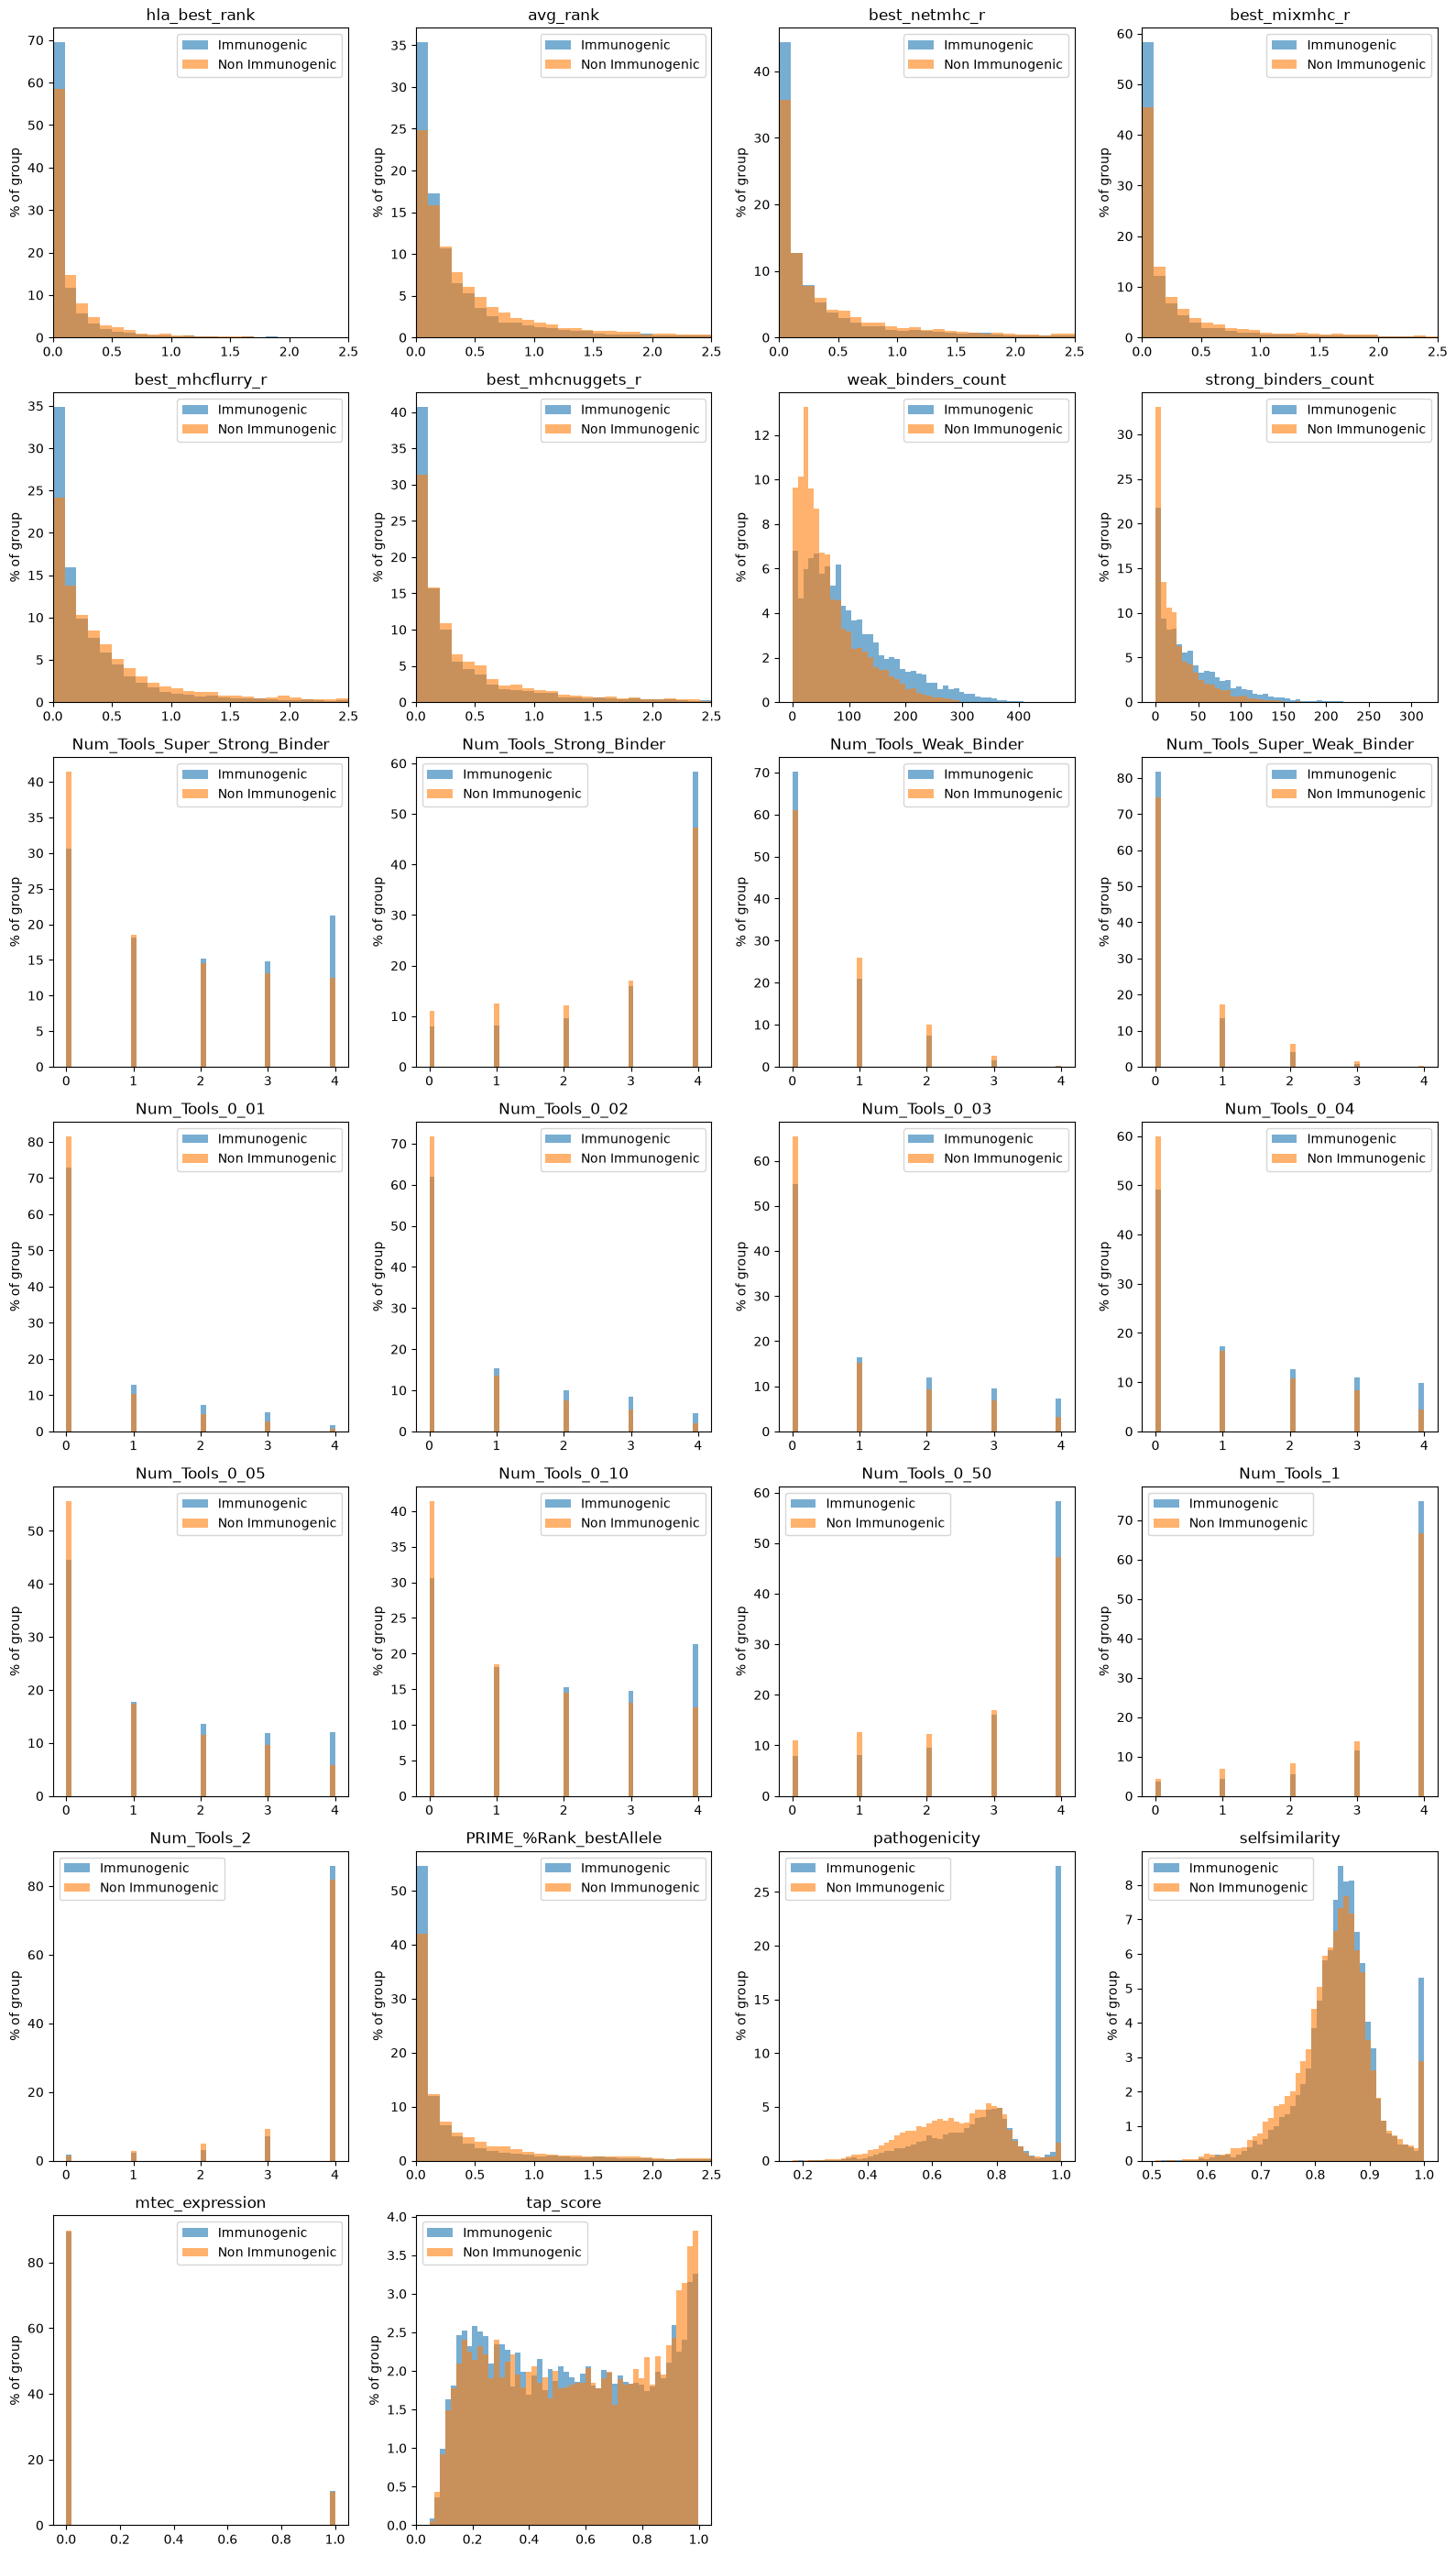

In [438]:
import numpy as np

feature_cols = X_df.drop(columns='peptide').columns
print(feature_cols)

def plotHistograms(X, feature_cols, labels):
    fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
    axes = axes.flatten()

    for i, feature in enumerate(feature_cols):
        data_pos = X[y == 1, i]
        data_neg = X[y == 0, i]

        # Restrict x-axis to [0, 5] for '_r' / 'PRIME' features, folding overflow into the last bin
        restrict_range = ('_r' in feature) or ('PRIME' in feature)
        if restrict_range:
            data_pos = np.clip(data_pos, 0, 5)
            data_neg = np.clip(data_neg, 0, 5)
            bins = np.linspace(0, 5, 51)
        else:
            # Shared bin edges across both groups so the comparison is meaningful
            combined = np.concatenate([data_pos, data_neg])
            bins = np.histogram_bin_edges(combined, bins=50)

        # Convert counts to percentage of that group's total datapoints
        weights_pos = np.ones_like(data_pos, dtype=float) * 100.0 / len(data_pos)
        weights_neg = np.ones_like(data_neg, dtype=float) * 100.0 / len(data_neg)

        axes[i].hist(data_pos, bins=bins, weights=weights_pos, alpha=0.6, label=labels[0])
        axes[i].hist(data_neg, bins=bins, weights=weights_neg, alpha=0.6, label=labels[1])
        axes[i].set_title(feature)
        axes[i].set_ylabel('% of group')
        if restrict_range:
            axes[i].set_xlim(0, 2.5)
        axes[i].legend()

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plotHistograms(X, feature_cols, ['Immunogenic', 'Non Immunogenic'])

In [431]:
# def plotBoxplots(X, feature_cols):
#     fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
#     axes = axes.flatten()

#     for i, feature in enumerate(feature_cols):
#         data = [X[y == 0, i], X[y == 1, i]]
#         axes[i].boxplot(data, label=['Non-immunogenic', 'Immunogenic'])
#         axes[i].set_title(feature)
#         axes[i].set_ylabel('Value')

#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# plotBoxplots(X, feature_cols)

### Feature Scaling

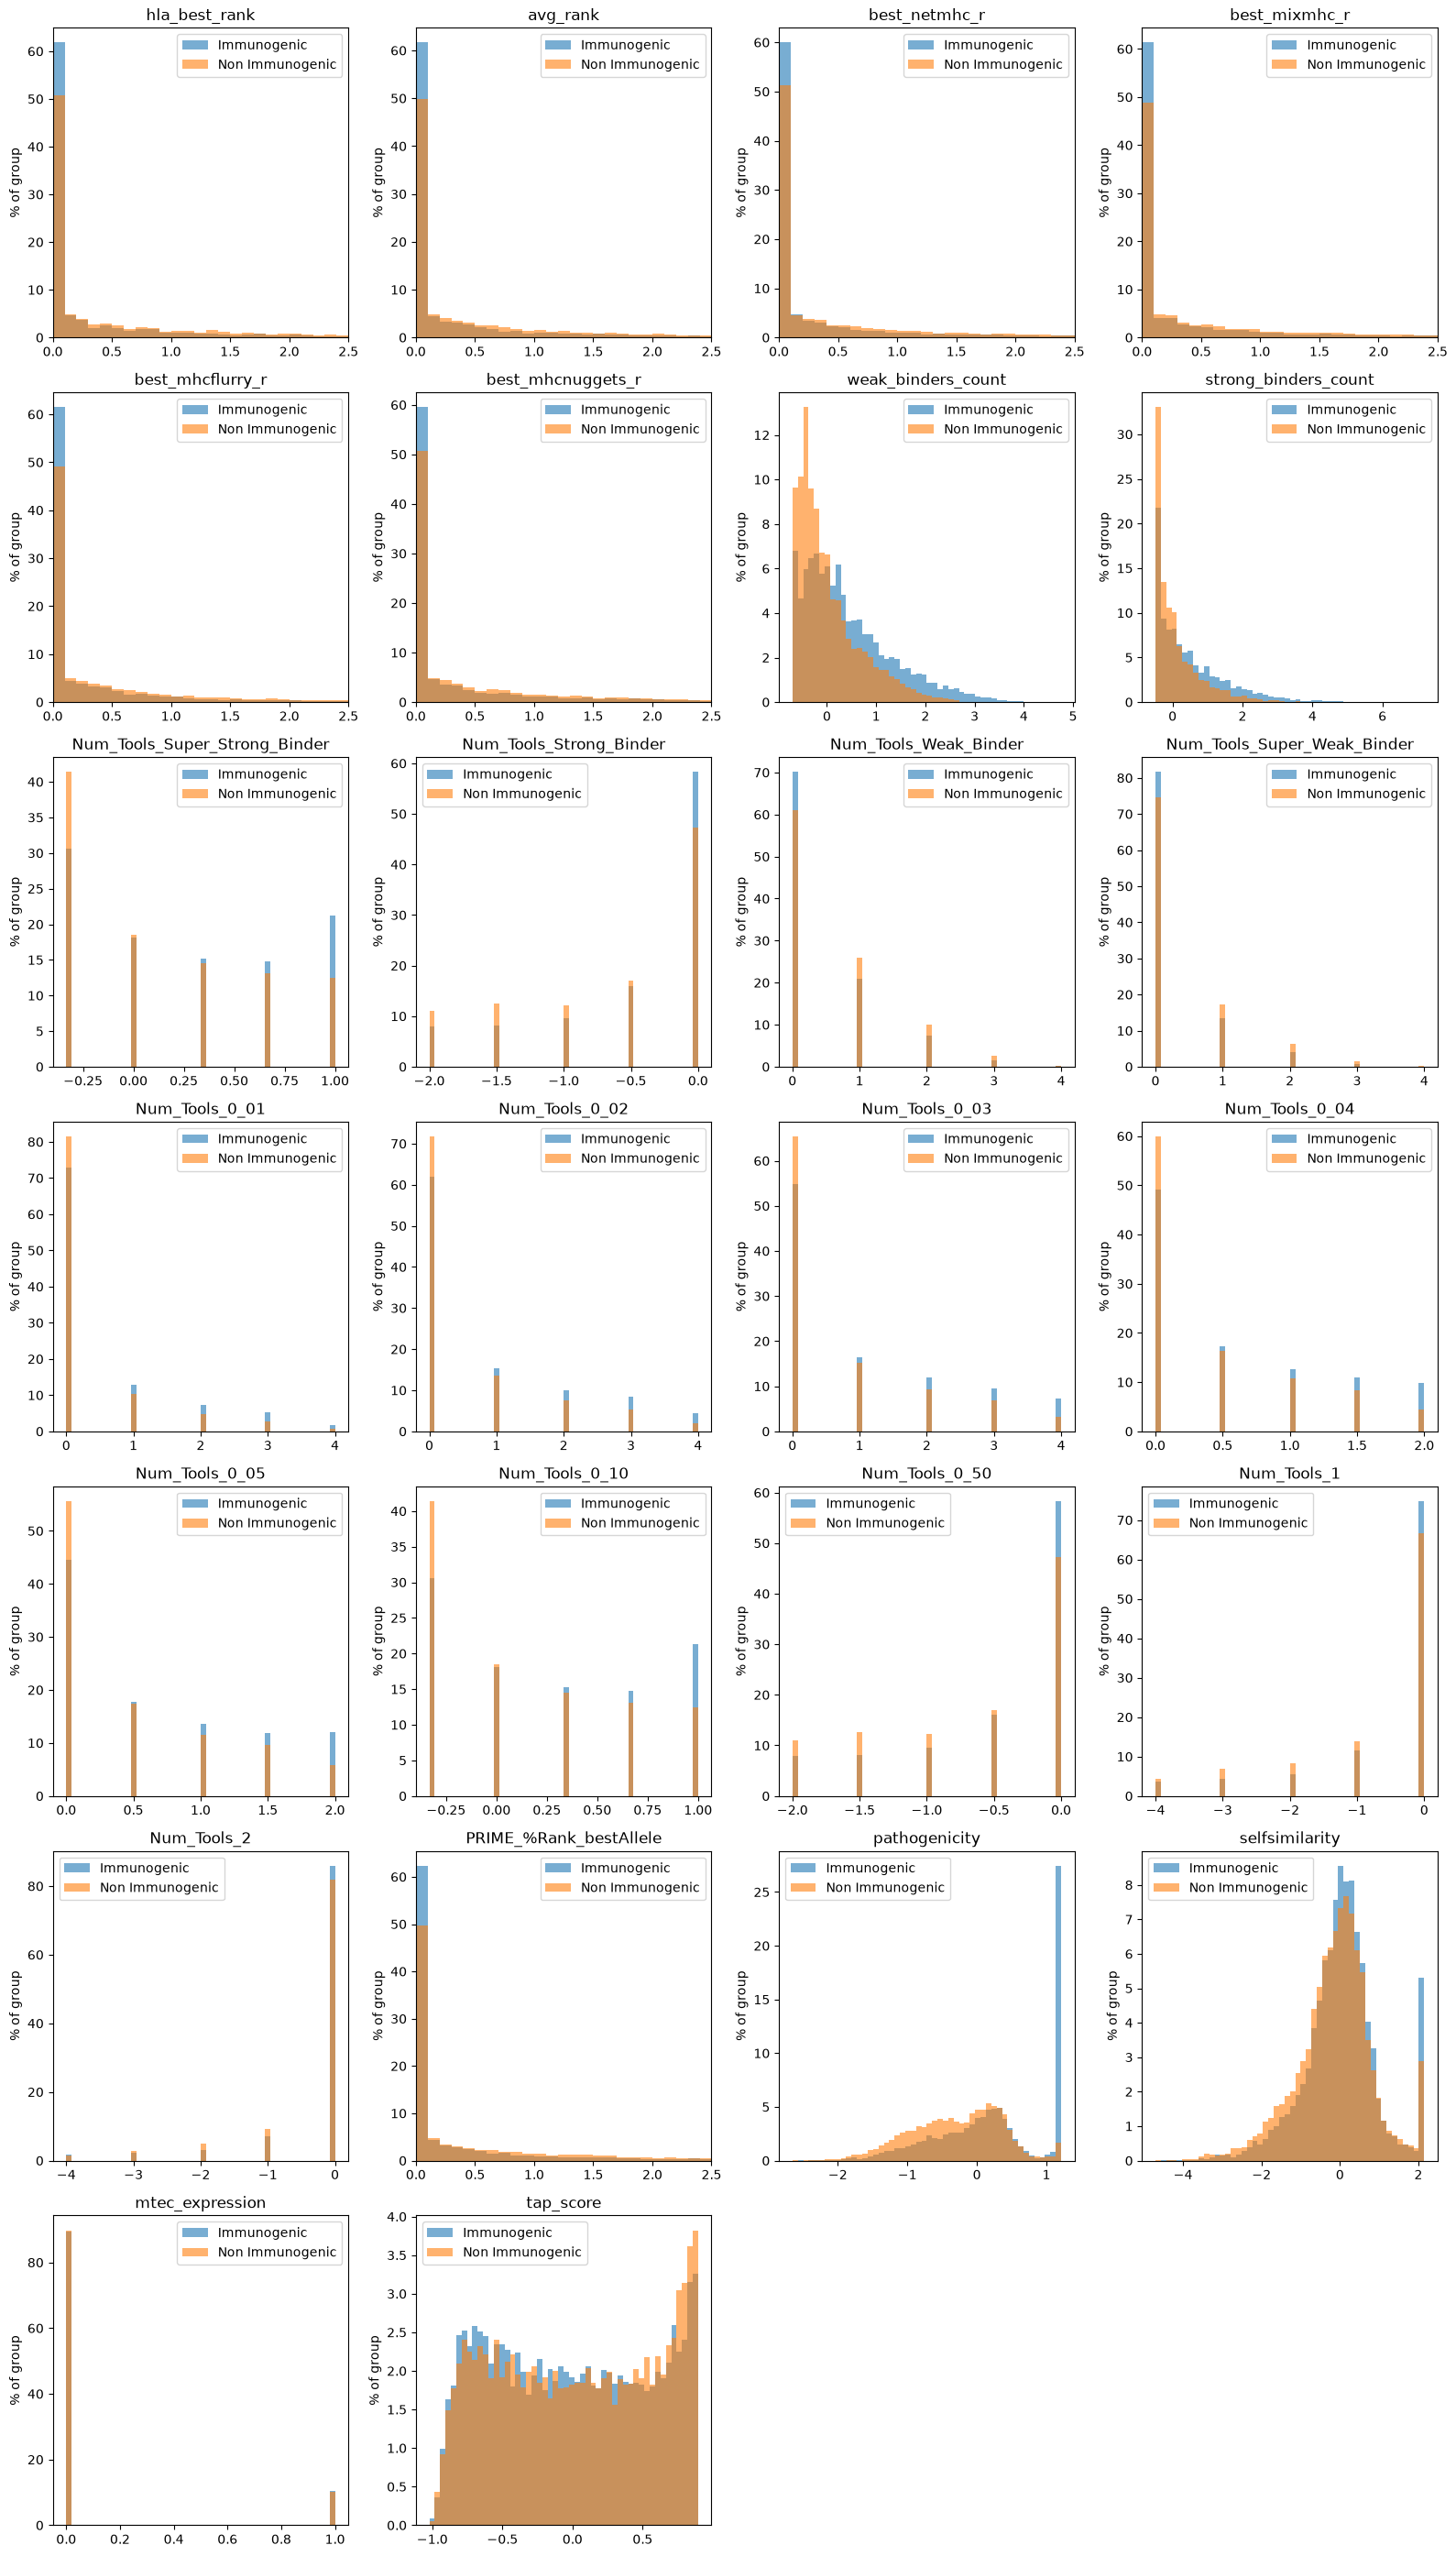

In [439]:
transformer = RobustScaler().fit(X)
X_scaled_Robust = transformer.transform(X)

#plotBoxplots(X_scaled_Robust, feature_cols)
plotHistograms(X_scaled_Robust, feature_cols, ['Immunogenic', 'Non Immunogenic'])

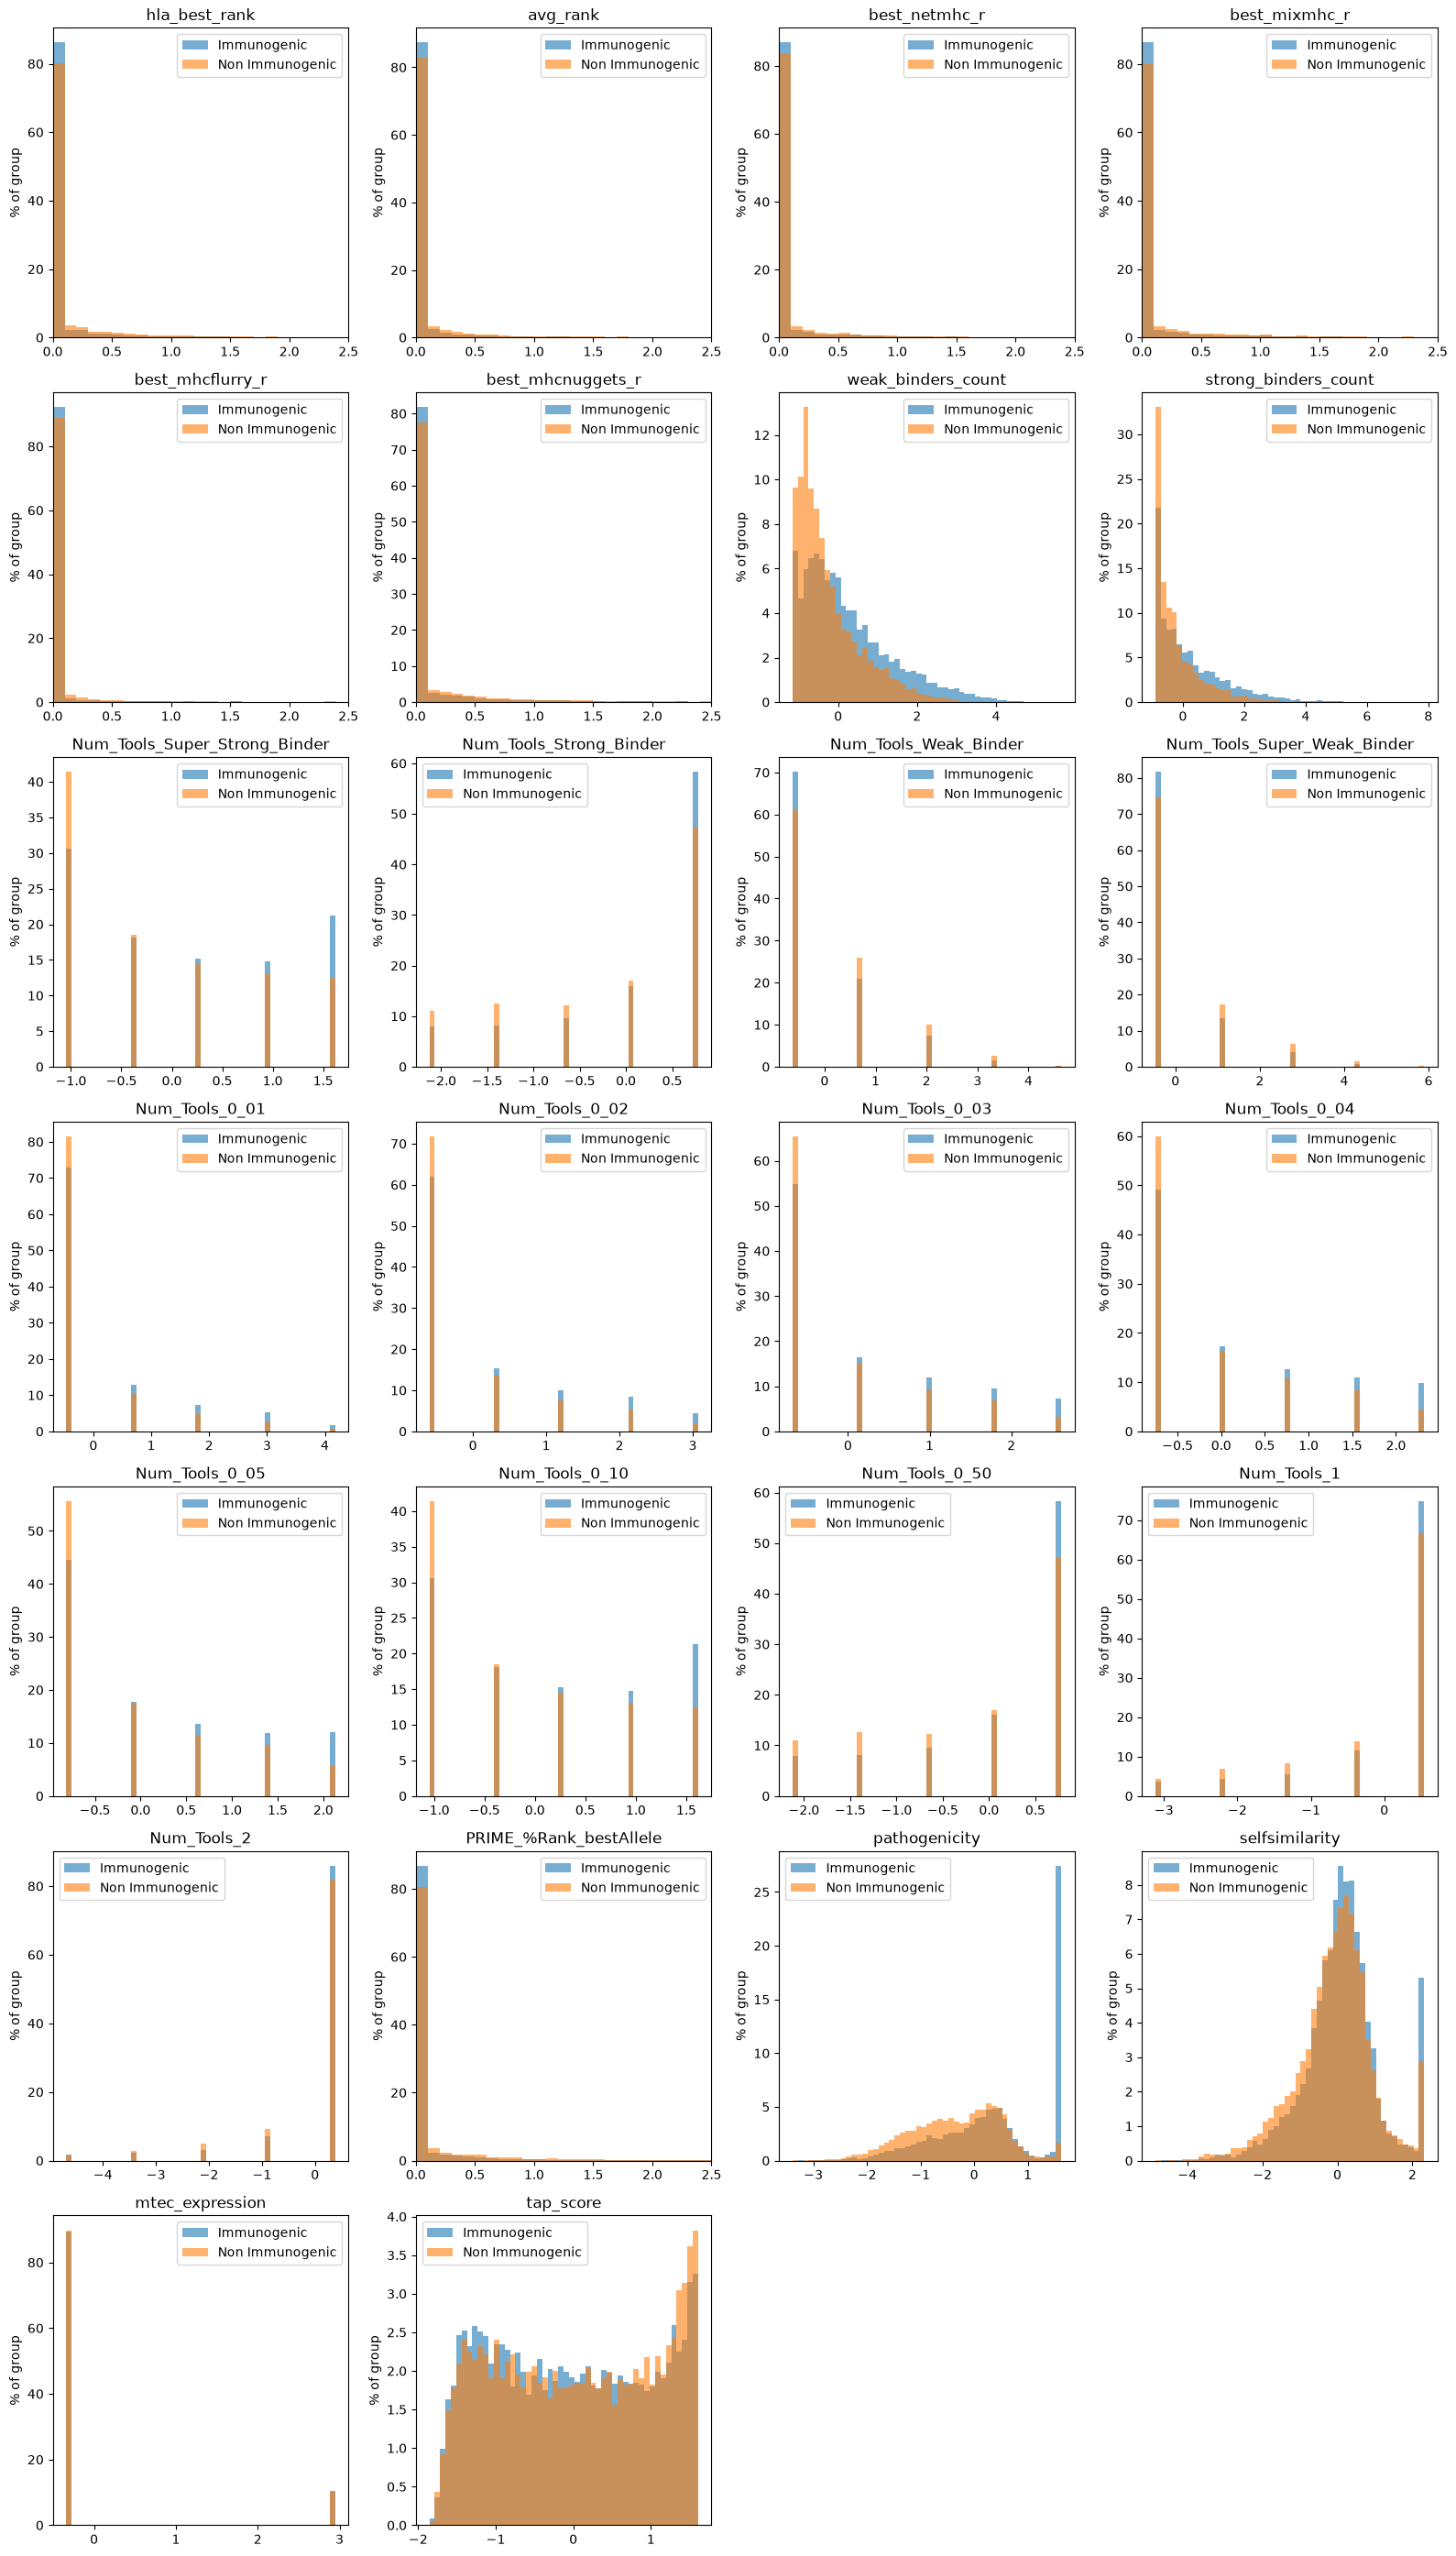

In [440]:
transformer = StandardScaler().fit(X)
X_scaled_Standard = transformer.transform(X)

#plotBoxplots(X_scaled_Standard, feature_cols)
plotHistograms(X_scaled_Standard, feature_cols, ['Immunogenic', 'Non Immunogenic'])

## SVM

### Removing Non-informative features

In [ ]:
display(X_df.columns)

X_df_final = X_df.drop(columns=['Num_Tools_Super_Strong_Binder', 'Num_Tools_Strong_Binder',
       'Num_Tools_Weak_Binder', 'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01',
       'Num_Tools_0_02', 'Num_Tools_0_03', 'Num_Tools_0_04' 'best_netmhc_r',
       'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r',], errors='ignore')

display(X_df_final.shape)

X = X_df_final.drop(columns='peptide').to_numpy()
display(X)

y = labels_df.drop(columns='peptide').to_numpy()
y=y.ravel()
display(y)


transformer = RobustScaler().fit(X)
X_scaled_Robust = transformer.transform(X)


Index(['peptide', 'hla_best_rank', 'avg_rank', 'best_netmhc_r',
       'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r',
       'weak_binders_count', 'strong_binders_count',
       'Num_Tools_Super_Strong_Binder', 'Num_Tools_Strong_Binder',
       'Num_Tools_Weak_Binder', 'Num_Tools_Super_Weak_Binder',
       'Num_Tools_0_01', 'Num_Tools_0_02', 'Num_Tools_0_03', 'Num_Tools_0_04',
       'Num_Tools_0_05', 'Num_Tools_0_10', 'Num_Tools_0_50', 'Num_Tools_1',
       'Num_Tools_2', 'PRIME_%Rank_bestAllele', 'pathogenicity',
       'selfsimilarity', 'mtec_expression', 'tap_score'],
      dtype='str')

(19499, 23)

array([[1.80000000e-02, 2.13500000e-01, 2.55000000e-01, ...,
        9.29203510e-01, 1.00000000e+00, 5.88600000e-01],
       [2.79000000e-01, 2.10500000e+00, 5.28200000e+00, ...,
        9.10891116e-01, 0.00000000e+00, 4.02800000e-01],
       [4.30000000e-02, 3.16000000e-01, 6.90000000e-01, ...,
        9.45454538e-01, 1.00000000e+00, 3.30900000e-01],
       ...,
       [5.00000000e-03, 4.87500000e-02, 3.30000000e-02, ...,
        8.13725471e-01, 0.00000000e+00, 9.37100000e-01],
       [3.00000000e-03, 1.07500000e-02, 3.00000000e-03, ...,
        8.61313879e-01, 0.00000000e+00, 7.83800000e-01],
       [1.10000000e-02, 5.75000000e-02, 1.22000000e-01, ...,
        8.26989591e-01, 0.00000000e+00, 8.06200000e-01]],
      shape=(19499, 22))

array([1, 0, 1, ..., 1, 1, 0], shape=(19499,))

### Feature Selection

#### RidgeCV

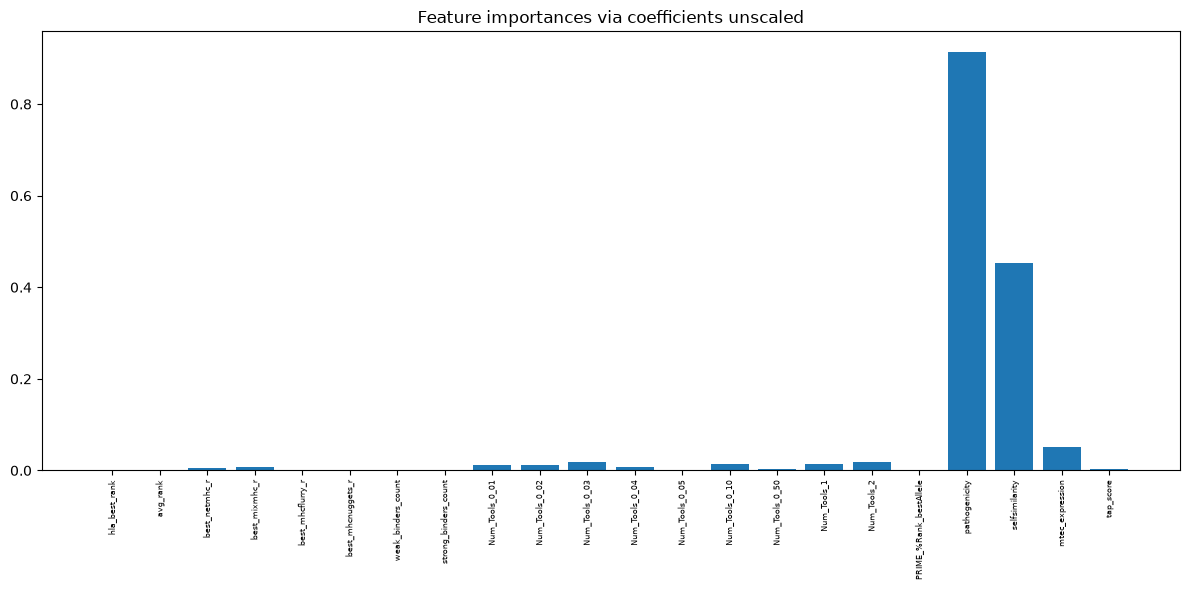

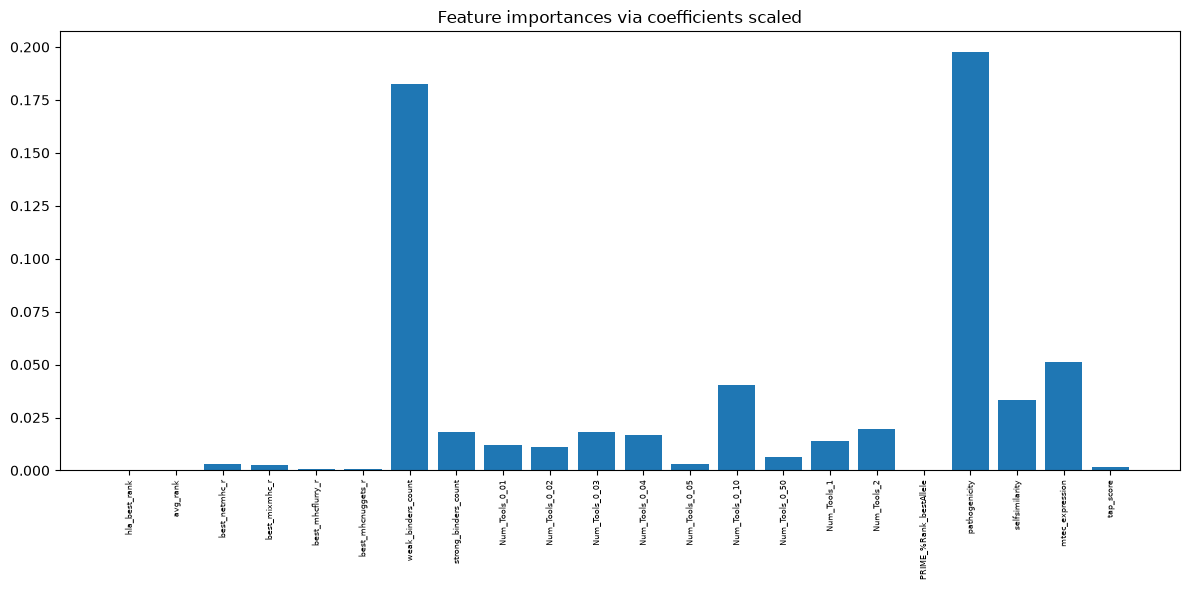

In [478]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X, y)
ridge_scaled = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X_scaled_Robust, y)
importance = np.abs(ridge.coef_)
importance_scaled = np.abs(ridge_scaled.coef_)

colnames = X_df_final.columns
feature_names = np.array(colnames.drop('peptide'))

plt.figure(figsize=(12, 6))
plt.bar(height=importance, x=feature_names)
plt.title("Feature importances via coefficients unscaled")
plt.xticks(rotation=90, fontsize=6, ha='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(height=importance_scaled, x=feature_names)
plt.title("Feature importances via coefficients scaled")
plt.xticks(rotation=90, fontsize=6, ha='center')
plt.tight_layout()
plt.show()

#### Sequential Feature Selection

In [479]:
from sklearn.feature_selection import SequentialFeatureSelector

def print_sfs_features(X, y, label: str):
    print(f'{label} dataset')  
    #tic_fwd = time()
    sfs_forward = SequentialFeatureSelector(
        ridge, n_features_to_select=5, direction="forward"
    ).fit(X, y)
    #toc_fwd = time()

    #tic_bwd = time()
    sfs_backward = SequentialFeatureSelector(
        ridge, n_features_to_select=5, direction="backward"
    ).fit(X, y)
    #toc_bwd = time()

    print(
        "Features selected by forward sequential selection: "
        f"{feature_names[sfs_forward.get_support()]}"
    )
    # print(f"Done in {toc_fwd - tic_fwd:.3f}s")
    print(
        "Features selected by backward sequential selection: "
        f"{feature_names[sfs_backward.get_support()]}"
    )
    # print(f"Done in {toc_bwd - tic_bwd:.3f}s")
    print('-'*60)

print_sfs_features(X, y, 'Standard')
print_sfs_features(X_scaled_Robust, y, 'Scaled')

Standard dataset
Features selected by forward sequential selection: ['weak_binders_count' 'Num_Tools_0_10' 'Num_Tools_2' 'pathogenicity'
 'selfsimilarity']
Features selected by backward sequential selection: ['weak_binders_count' 'Num_Tools_0_03' 'Num_Tools_1' 'pathogenicity'
 'selfsimilarity']
------------------------------------------------------------
Scaled dataset
Features selected by forward sequential selection: ['weak_binders_count' 'Num_Tools_0_10' 'Num_Tools_2' 'pathogenicity'
 'selfsimilarity']
Features selected by backward sequential selection: ['weak_binders_count' 'Num_Tools_0_03' 'Num_Tools_1' 'pathogenicity'
 'selfsimilarity']
------------------------------------------------------------


#### Tree-based feature selection

In [490]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

display(X.shape)

clf = ExtraTreesClassifier(n_estimators=50)
clf = clf.fit(X, y)
display(clf.feature_importances_)

print(len(X_df_final.drop(columns=['peptide']).columns))
print(len(clf.feature_importances_))
      
for col, imp in zip(X_df_final.drop(columns=['peptide']).columns, clf.feature_importances_):
    print(f"{col}: {imp}")

model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
display(X_new.shape)

(19499, 22)

array([0.05316874, 0.05772514, 0.05988484, 0.05678452, 0.05839933,
       0.05498525, 0.09297563, 0.07386757, 0.01129958, 0.01204177,
       0.01218093, 0.01292371, 0.01558398, 0.02315736, 0.0181353 ,
       0.01380552, 0.00840101, 0.05819274, 0.16986429, 0.06203942,
       0.01302504, 0.06155831])

22
22
hla_best_rank: 0.05316874169616522
avg_rank: 0.05772513621516176
best_netmhc_r: 0.059884838982392774
best_mixmhc_r: 0.056784521056414176
best_mhcflurry_r: 0.05839932957868539
best_mhcnuggets_r: 0.054985249249657545
weak_binders_count: 0.09297562516381701
strong_binders_count: 0.07386757480689085
Num_Tools_0_01: 0.011299582620784454
Num_Tools_0_02: 0.01204177312960694
Num_Tools_0_03: 0.012180928376010041
Num_Tools_0_04: 0.012923709638420393
Num_Tools_0_05: 0.015583982316145549
Num_Tools_0_10: 0.023157361186961826
Num_Tools_0_50: 0.018135298139733726
Num_Tools_1: 0.013805521971531294
Num_Tools_2: 0.00840101447060945
PRIME_%Rank_bestAllele: 0.05819274448406017
pathogenicity: 0.16986429048216867
selfsimilarity: 0.0620394187715755
mtec_expression: 0.013025043376419297
tap_score: 0.061558314286788


(19499, 12)

#### L1-based feature selection

In [496]:
from sklearn.svm import LinearSVC

display(X.shape)

lsvc = LinearSVC(C=0.01, penalty="l1", dual=False).fit(X, y)
model = SelectFromModel(lsvc, prefit=True)
X_new = model.transform(X)
display(X_new.shape)

(19499, 22)

(19499, 17)

#### Recursive Feature Elimination with Cross Validation

In [515]:
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import StratifiedKFold

min_features_to_select = 2  # Minimum number of features to consider
clf = LinearSVC(C=0.01)
cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="precision",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv.fit(X, y)

print(f"Optimal number of features: {rfecv.n_features_}")

Optimal number of features: 19


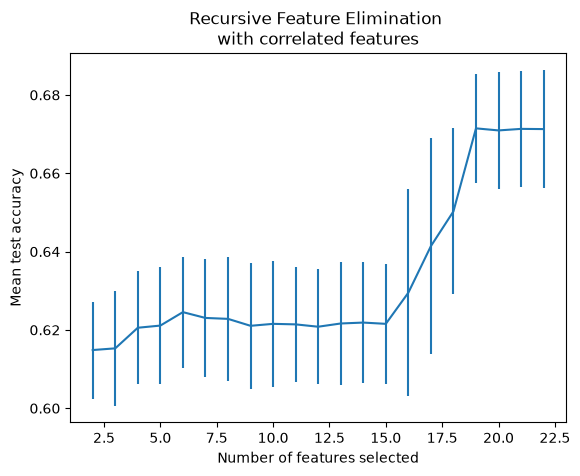

In [509]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [510]:
import numpy as np

for i in range(cv.n_splits):
    mask = rfecv.cv_results_[f"split{i}_support"][
        rfecv.n_features_ - 1
    ]  # mask of features selected by the RFE
    features_selected = np.ma.compressed(np.ma.masked_array(X_df_final.drop(columns=['peptide']).columns, mask=1 - mask))
    print(f"Features selected in fold {i} ({len(features_selected)}): {features_selected}")

Features selected in fold 0 (20): ['hla_best_rank' 'avg_rank' 'best_netmhc_r' 'best_mixmhc_r'
 'best_mhcnuggets_r' 'weak_binders_count' 'Num_Tools_0_01'
 'Num_Tools_0_02' 'Num_Tools_0_03' 'Num_Tools_0_04' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_0_50' 'Num_Tools_1' 'Num_Tools_2'
 'PRIME_%Rank_bestAllele' 'pathogenicity' 'selfsimilarity'
 'mtec_expression' 'tap_score']
Features selected in fold 1 (20): ['hla_best_rank' 'best_netmhc_r' 'best_mixmhc_r' 'best_mhcnuggets_r'
 'weak_binders_count' 'strong_binders_count' 'Num_Tools_0_01'
 'Num_Tools_0_02' 'Num_Tools_0_03' 'Num_Tools_0_04' 'Num_Tools_0_05'
 'Num_Tools_0_10' 'Num_Tools_0_50' 'Num_Tools_1' 'Num_Tools_2'
 'PRIME_%Rank_bestAllele' 'pathogenicity' 'selfsimilarity'
 'mtec_expression' 'tap_score']
Features selected in fold 2 (20): ['hla_best_rank' 'avg_rank' 'best_netmhc_r' 'best_mixmhc_r'
 'best_mhcflurry_r' 'best_mhcnuggets_r' 'weak_binders_count'
 'Num_Tools_0_01' 'Num_Tools_0_02' 'Num_Tools_0_03' 'Num_Tools_0_04'
 'Num_Tools_

#### Random Forest Feature Importance

In [529]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

feature_names = [f"feature {i}" for i in range(X.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [530]:
import time

import numpy as np

start_time = time.time()
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.195 seconds


Feature Importance based on Mean Decrease in Impurity (MDI)

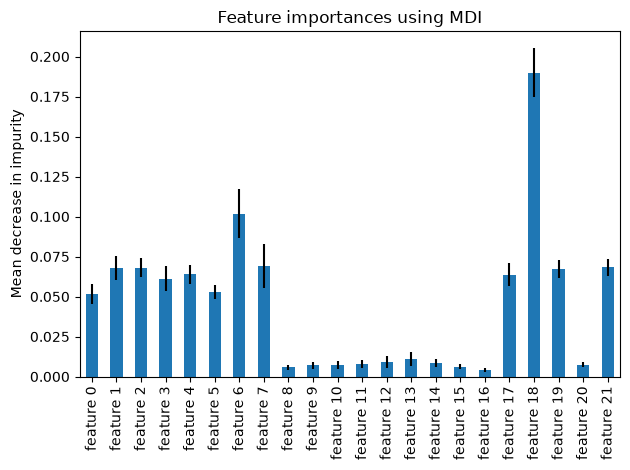

In [531]:
import pandas as pd

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

Feature Importance based on feature permutation

In [532]:
from sklearn.inspection import permutation_importance

start_time = time.time()
result = permutation_importance(
    forest, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=feature_names)

Elapsed time to compute the importances: 21.547 seconds


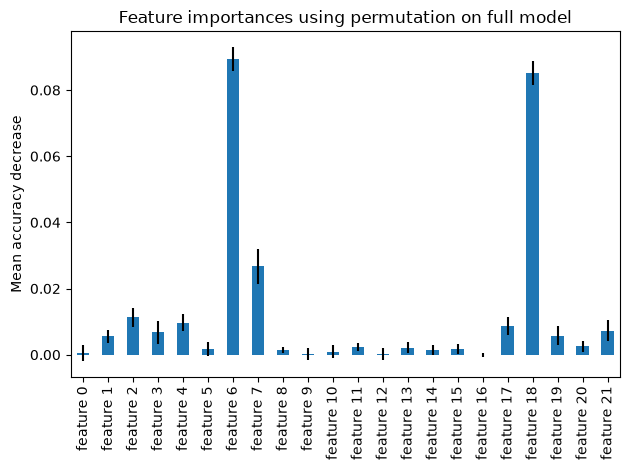

In [533]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

Features 0-7 and 18

In [537]:
display(X_df_final.drop(columns=['peptide']).columns[0:6])
display(X_df_final.drop(columns=['peptide']).columns[18])
display(X_df_final.drop(columns=['peptide']).columns[6])
display(X_df_final.drop(columns=['peptide']).columns[7])

Index(['hla_best_rank', 'avg_rank', 'best_netmhc_r', 'best_mixmhc_r',
       'best_mhcflurry_r', 'best_mhcnuggets_r'],
      dtype='str')

'pathogenicity'

'weak_binders_count'

'strong_binders_count'

#### Univariate Feature Selection
does not work

In [527]:
from sklearn.feature_selection import SelectKBest, f_classif

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled_Robust, y, test_size=0.2, random_state=42)

selector = SelectKBest(f_classif, k=20)
selector.fit(X_train, y_train)
scores = -np.log10(selector.pvalues_)
scores /= scores.max()

/var/folders/3l/3p0t5hpd41nftsr1xnzqh0wc0000gn/T/ipykernel_85079/3852461499.py:8: RuntimeWarning: divide by zero encountered in log10
  scores = -np.log10(selector.pvalues_)
/var/folders/3l/3p0t5hpd41nftsr1xnzqh0wc0000gn/T/ipykernel_85079/3852461499.py:9: RuntimeWarning: invalid value encountered in divide
  scores /= scores.max()


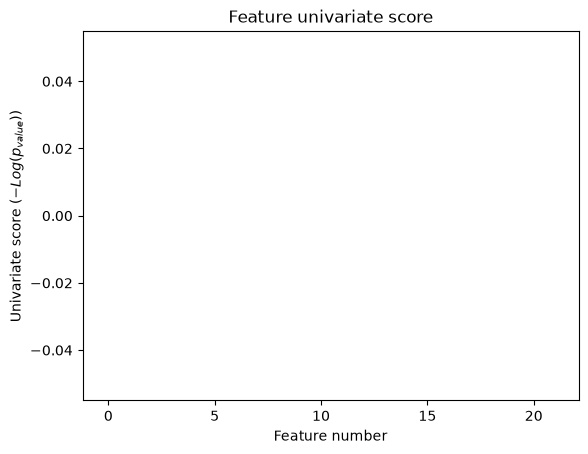

In [528]:
import matplotlib.pyplot as plt

X_indices = np.arange(X.shape[-1])
plt.figure(1)
plt.clf()
plt.bar(X_indices - 0.05, scores, width=0.2)
plt.title("Feature univariate score")
plt.xlabel("Feature number")
plt.ylabel(r"Univariate score ($-Log(p_{value})$)")
plt.show()

### Train Test split

In [447]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(f"X_train: {X_train.shape}")
display(f"X_test: {X_test.shape}")
display(f"y_train: {y_train.shape}")
display(f"y_test: {y_test.shape}")

X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled_Robust, y, test_size=0.2, random_state=42)

'X_train: (15599, 22)'

'X_test: (3900, 22)'

'y_train: (15599,)'

'y_test: (3900,)'

In [449]:
# C = 1.0  # SVM regularization parameter
# models = (
#     svm.SVC(kernel="linear", C=C),
#     svm.LinearSVC(C=C, max_iter=10000),
#     svm.SVC(kernel="rbf", gamma=0.7, C=C),
#     svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
# )
# models = (clf.fit(X, y) for clf in models)

scoring = ['precision_macro', 'recall_macro']
#clf = svm.SVC(kernel='linear', C=10, random_state=0)
clf = svm.LinearSVC(C=10, random_state=0, max_iter=10000)
scores = cross_validate(clf, X, y, scoring=scoring, n_jobs=-1)
sorted(scores.keys())

scores_scaled = cross_validate(clf, X_scaled_Robust, y, scoring=scoring, n_jobs=-1)


In [465]:
scoring = ['precision_macro', 'recall_macro']
#clf = svm.SVC(kernel='linear', C=10, random_state=0)
clf = svm.SVC(kernel='rbf', C=10, random_state=0, gamma=0.1)
scores = cross_validate(clf, X, y, scoring=scoring, n_jobs=-1)
sorted(scores.keys())

scores_scaled = cross_validate(clf, X_scaled_Robust, y, scoring=scoring, n_jobs=-1)

KeyboardInterrupt: 

In [453]:
print("Test Scores")

display(f"Precision: {scores['test_precision_macro']}")
display(f"Recall: {scores['test_recall_macro']}")
display("Scaled")
display(f"Precision: {scores_scaled['test_precision_macro']}")
display(f"Recall: {scores_scaled['test_recall_macro']}")

Test Scores


'Precision: [0.65603042 0.64511292 0.65403292 0.6743676  0.67057609]'

'Recall: [0.65474207 0.64462795 0.65208388 0.6703372  0.67023828]'

'Scaled'

'Precision: [0.65603042 0.64507539 0.6543085  0.67465565 0.67056496]'

'Recall: [0.65474207 0.64464137 0.65233807 0.67059126 0.67024288]'

In [455]:
# # Number of random trials
# NUM_TRIALS = 2

# # Set up possible values of parameters to optimize over
# p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1]}

# # We will use a Support Vector Classifier with "rbf" kernel
# svc = svm.SVC(kernel="rbf")

# # Arrays to store scores
# nested_scores = np.zeros(NUM_TRIALS)

# # Loop for each trial
# for i in range(NUM_TRIALS):
#     # Choose cross-validation techniques for the inner and outer loops,
#     # independently of the dataset.
#     # E.g "GroupKFold", "LeaveOneOut", "LeaveOneGroupOut", etc.
#     inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
#     outer_cv = KFold(n_splits=4, shuffle=True, random_state=i)

#     # Nested CV with parameter optimization
#     clf = GridSearchCV(estimator=svc, param_grid=p_grid, cv=inner_cv)
#     nested_score = cross_val_score(clf, X=X_scaled_train, y=y_train, cv=outer_cv)
#     nested_scores[i] = nested_score.mean()

In [ ]:
print(X.shape)
print(y.shape)

from sklearn.utils import resample
X_sample, y_sample = resample(X, y, n_samples=500, random_state=42)


(19499, 22)
(19499,)
(19499, 22)
(19499,)


In [464]:
from sklearn import svm
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Parameter grid: each dict is its own independent search space,
# so gamma is only tested with kernels that actually use it.
# ------------------------------------------------------------------
p_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"],    "svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1]},
    #{"svc__kernel": ["poly"],   "svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1], "svc__degree": [2, 3]},
]

# ------------------------------------------------------------------
# Wrap in a Pipeline. Best practice even if scaling is already done —
# it also makes adding preprocessing steps later trivial.
# The svc__ prefix in p_grid above maps to the pipeline step name.
# ------------------------------------------------------------------
pipe = Pipeline([("svc", svm.SVC())])

# ------------------------------------------------------------------
# Nested CV — single pass, no repeated trials
# ------------------------------------------------------------------
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv  = KFold(n_splits=5, shuffle=True, random_state=42)

clf = GridSearchCV(
    estimator=pipe,
    param_grid=p_grid,
    cv=inner_cv,
    scoring="precision",
    n_jobs=-1,
    refit=True,                    # refit best model on the full inner fold data
    return_train_score=True,       # lets you diagnose overfitting later
    verbose=1
)

nested_scores = cross_val_score(clf, X=X, y=y, cv=outer_cv, scoring="precision")

print(f"Nested CV precision: {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/jonathan/Documents/icr/ipp/ImmunPepPred/models/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jonathan/Documents/icr/ipp/ImmunPepPred/models/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jonathan/Documents/icr/ipp/ImmunPepPred/models/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this b

KeyboardInterrupt: 

In [130]:
# ------------------------------------------------------------------
# Identify the best hyperparameters: refit GridSearchCV on the 
# full training set so you can inspect best_params_ and best_score_
# ------------------------------------------------------------------
clf.fit(X_sample, y_sample)

print(f"\nBest params:  {clf.best_params_}")
print(f"Best inner CV score: {clf.best_score_:.4f}")

# ------------------------------------------------------------------
# Summary table of all candidates — useful for comparing kernels
# ------------------------------------------------------------------
results_df = pd.DataFrame(clf.cv_results_)[
    ["param_svc__kernel", "param_svc__C", "param_svc__gamma", "param_svc__degree",
     "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
].sort_values("rank_test_score")

print("\nTop 10 parameter combinations:")
print(results_df.head(10).to_string(index=False))

print("\nBottom 10 parameter combinations:")
print(results_df.tail(10).to_string(index=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params:  {'svc__C': 10, 'svc__kernel': 'linear'}
Best inner CV score: 0.6360

Top 10 parameter combinations:
param_svc__kernel  param_svc__C  param_svc__gamma  param_svc__degree  mean_test_score  std_test_score  mean_train_score  rank_test_score
           linear          10.0               NaN                NaN            0.636        0.018547            0.6465                1
           linear           1.0               NaN                NaN            0.632        0.016000            0.6425                2
           linear           0.1               NaN                NaN            0.626        0.028705            0.6375                3
              rbf          10.0              0.01                NaN            0.624        0.025768            0.6720                4
              rbf           1.0              0.01                NaN            0.618        0.044000            0.6375                5
 